# Comparativa de Modelos de Machine Learning
### Dataset: Big Five Personality Test (IPIP-FFM)
Comparación entre **Random Forest**, Regresión Lineal, Árbol de Decisión y KNN  
para predecir el rasgo de **Extraversión (EXT)**.


In [1]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_7cdc23c65e220f5584d40f70c44ff013'

In [2]:
import kagglehub

path = kagglehub.dataset_download("tunguz/big-five-personality-test")
print("Dataset descargado en:", path)

/home/angela/dev/projects/tcsm-project-g2/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset descargado en: /home/angela/.cache/kagglehub/datasets/tunguz/big-five-personality-test/versions/1


## 1. Carga y Exploración del Dataset

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(f"{path}/IPIP-FFM-data-8Nov2018/data-final.csv", sep='\t')
print(f"Shape original: {df.shape}")
df.head()

Shape original: (1015341, 110)


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [4]:
# Información general
print("Tipos de datos:")
print(df.dtypes.value_counts())
print(f"\nValores nulos: {df.isnull().sum().sum()}")
print(f"Valores -1 (inválidos): {(df == -1).sum().sum()}")

Tipos de datos:
float64    104
str          4
int64        2
Name: count, dtype: int64

Valores nulos: 186358
Valores -1 (inválidos): 0


## 2. Preprocesamiento de Datos

In [5]:
# Limpieza: reemplazar -1 y nulos
df = df.replace(-1, 0)
df = df.fillna(0)

# Muestra representativa reproducible
df = df.sample(n=10000, random_state=42)

# Variable objetivo: promedio de ítems de Extraversión
df["EXT"] = df[["EXT1","EXT2","EXT3","EXT4","EXT5","EXT6","EXT7","EXT8","EXT9","EXT10"]].mean(axis=1)

# Features: todo menos los ítems EXT y la variable objetivo
cols_to_drop = [col for col in df.columns if "EXT" in col] + [
    "screenw",
    "screenh",
    "introelapse",
    "testelapse",
    "endelapse",
    "IPC",
    "lat_appx_lots_of_err",
    "long_appx_lots_of_err",
    "dateload",
]
X = df.drop(cols_to_drop, axis=1)
X = X.select_dtypes(include=['number'])

y = df["EXT"]

print(f"Features: {X.shape[1]} columnas")
print(f"Muestras: {X.shape[0]} filas")
print(f"Variable objetivo (EXT) - media: {y.mean():.3f}, std: {y.std():.3f}")

Features: 80 columnas
Muestras: 10000 filas
Variable objetivo (EXT) - media: 3.018, std: 0.390


/tmp/ipykernel_2283238/2378954512.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EXT"] = df[["EXT1","EXT2","EXT3","EXT4","EXT5","EXT6","EXT7","EXT8","EXT9","EXT10"]].mean(axis=1)


## 3. División Train / Test

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 8000 muestras
Test:  2000 muestras


## 4. Definición de Modelos

Se comparan 4 algoritmos:
- **Random Forest** — Ensemble robusto de árboles de decisión con bagging
- **Regresión Lineal** — Baseline paramétrico clásico
- **Árbol de Decisión** — Modelo simple no lineal, propenso a overfitting
- **KNN (K-Nearest Neighbors)** — Método basado en similitud local


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Random Forest":       RandomForestRegressor(
                               n_estimators=200,
                               max_features='sqrt',
                               min_samples_leaf=2,
                               max_depth=20,
                               n_jobs=-1,
                               random_state=42
                           ),
    "Regresión Lineal":    LinearRegression(),
    "Árbol de Decisión":   DecisionTreeRegressor(
                               max_depth=10,
                               min_samples_leaf=5,
                               random_state=42
                           ),
    "KNN":                 KNeighborsRegressor(
                               n_neighbors=10,
                               weights='distance'
                           ),
}

## 5. Entrenamiento y Evaluación

In [8]:
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

print(f"{'Modelo':<22} {'MSE':>8} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Tiempo':>8}")
print("-" * 66)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0

    y_pred = model.predict(X_test)

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2, "Tiempo": elapsed}

    print(f"{name:<22} {mse:>8.4f} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f} {elapsed:>7.2f}s")

Modelo                      MSE     RMSE      MAE       R²   Tiempo
------------------------------------------------------------------
Random Forest            0.1035   0.3217   0.2488   0.3013    0.69s
Regresión Lineal         0.1150   0.3391   0.2584   0.2238    0.02s
Árbol de Decisión        0.1293   0.3596   0.2770   0.1267    0.28s
KNN                      0.1299   0.3604   0.2773   0.1232    0.00s


In [9]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
best_model = results_df.index[0]

print("\nResultados ordenados por R² (mayor es mejor):")
print(results_df.to_string())
print(f"\nMejor modelo: {best_model}")


Resultados ordenados por R² (mayor es mejor):
                        MSE      RMSE       MAE        R2    Tiempo
Random Forest      0.103489  0.321697  0.248837  0.301289  0.687232
Regresión Lineal   0.114972  0.339076  0.258407  0.223758  0.022435
Árbol de Decisión  0.129341  0.359640  0.277036  0.126746  0.281181
KNN                0.129873  0.360379  0.277348  0.123156  0.003591

Mejor modelo: Random Forest


## 6. Visualización Comparativa

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_style("whitegrid")
COLORS = {
    "Random Forest":     "#2ecc71",
    "Regresión Lineal":  "#3498db",
    "Árbol de Decisión": "#e67e22",
    "KNN":               "#e74c3c",
}
model_names = list(results.keys())
colors = [COLORS[m] for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparativa de Modelos — Big Five Personality (Extraversión)",
             fontsize=14, fontweight='bold', y=1.02)

# --- MSE (menor es mejor) ---
ax = axes[0]
mse_vals = [results[m]["MSE"] for m in model_names]
bars = ax.bar(model_names, mse_vals, color=colors, edgecolor='white', linewidth=1.2)
ax.set_title("MSE (↓ mejor)", fontweight='bold')
ax.set_ylabel("Mean Squared Error")
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, mse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha='center', va='bottom', fontsize=8)
ax.bar_label(bars, labels=[''], padding=3)

# --- MAE (menor es mejor) ---
ax = axes[1]
mae_vals = [results[m]["MAE"] for m in model_names]
bars = ax.bar(model_names, mae_vals, color=colors, edgecolor='white', linewidth=1.2)
ax.set_title("MAE (↓ mejor)", fontweight='bold')
ax.set_ylabel("Mean Absolute Error")
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha='center', va='bottom', fontsize=8)

# --- R² (mayor es mejor) ---
ax = axes[2]
r2_vals = [results[m]["R2"] for m in model_names]
bars = ax.bar(model_names, r2_vals, color=colors, edgecolor='white', linewidth=1.2)
ax.set_title("R² (↑ mejor)", fontweight='bold')
ax.set_ylabel("Coeficiente de Determinación R²")
ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0, min(1.0, max(r2_vals) * 1.15))
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("comparativa_modelos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como comparativa_modelos.png")

ModuleNotFoundError: No module named 'seaborn'

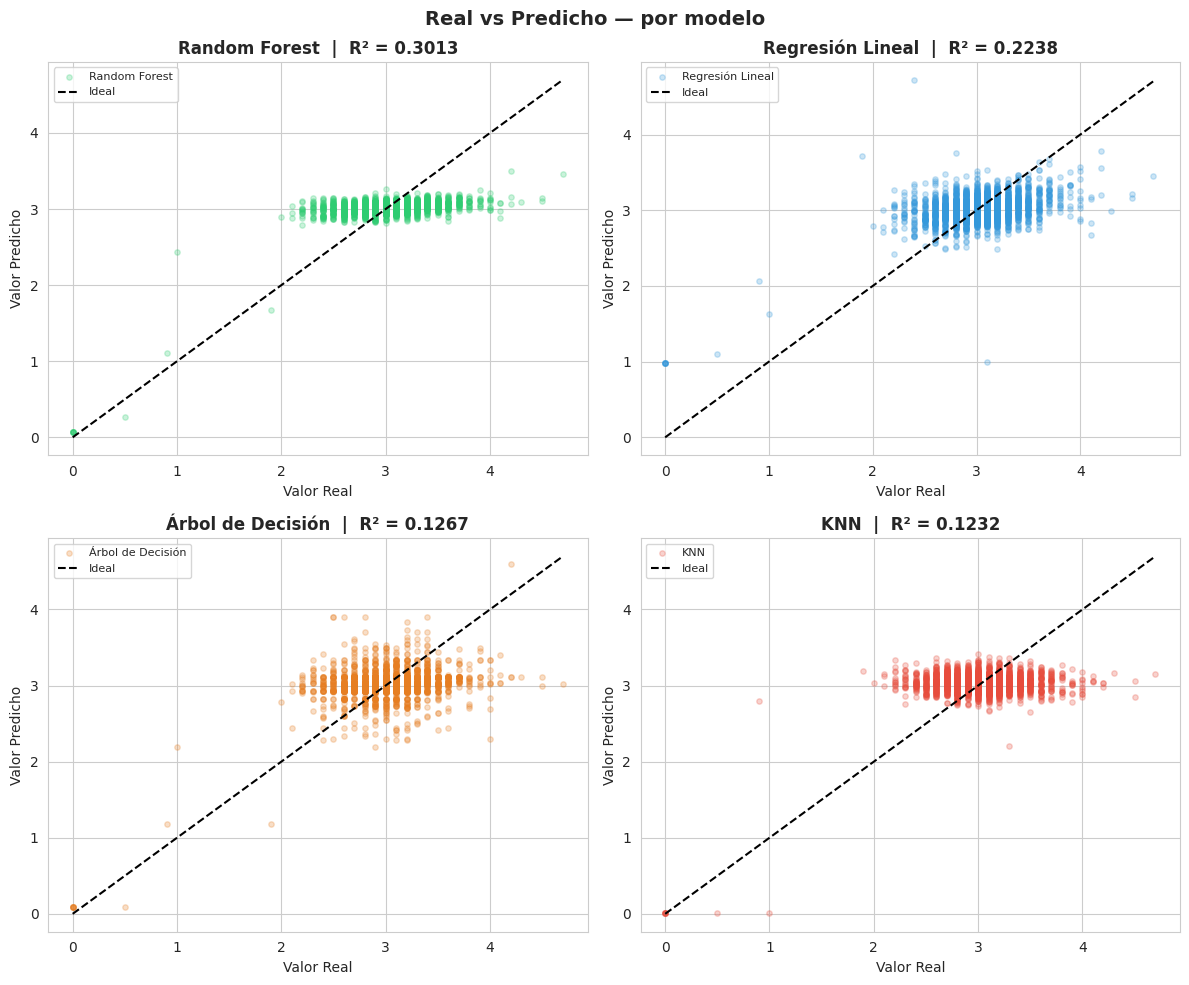

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Real vs Predicho — por modelo", fontsize=14, fontweight='bold')

axes_flat = axes.flatten()

for ax, (name, model) in zip(axes_flat, models.items()):
    y_pred = model.predict(X_test)
    r2 = results[name]["R2"]
    color = COLORS[name]

    ax.scatter(y_test, y_pred, alpha=0.25, s=15, color=color, label=name)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label="Ideal")
    ax.set_xlabel("Valor Real")
    ax.set_ylabel("Valor Predicho")
    ax.set_title(f"{name}  |  R² = {r2:.4f}", fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("real_vs_predicho.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Importancia de Variables — Random Forest

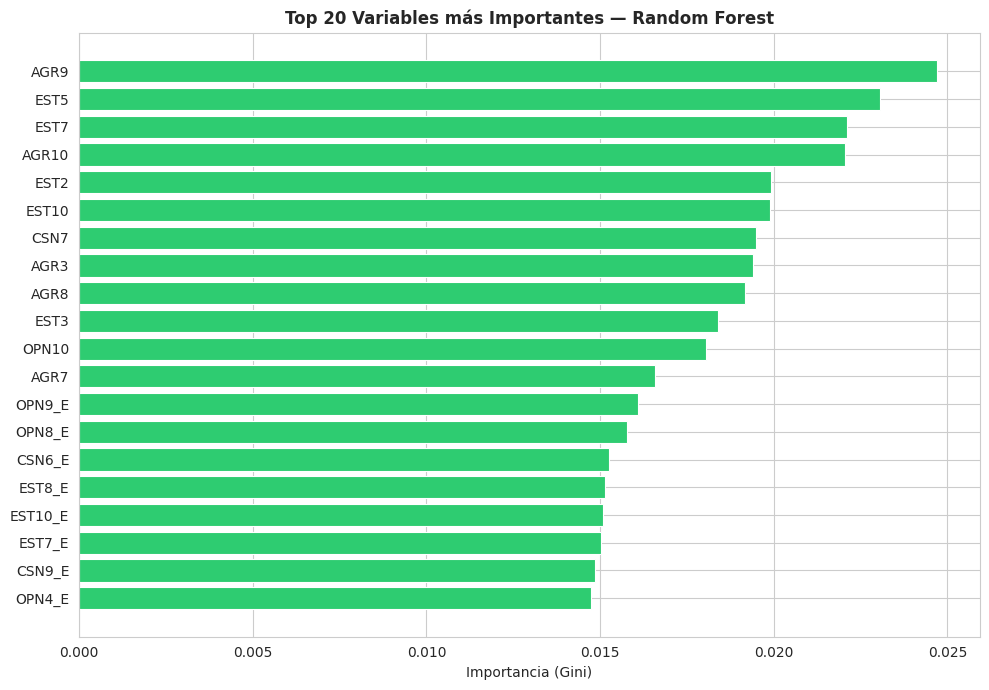


Top 10 variables más importantes:
Feature  Importancia
   AGR9     0.024702
   EST5     0.023053
   EST7     0.022102
  AGR10     0.022063
   EST2     0.019910
  EST10     0.019879
   CSN7     0.019501
   AGR3     0.019393
   AGR8     0.019186
   EST3     0.018380


In [ ]:
rf = models["Random Forest"]
importances = rf.feature_importances_
feature_names = X.columns.tolist()

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importancia": importances
}).sort_values("Importancia", ascending=False).head(20)

plt.figure(figsize=(10, 7))
bars = plt.barh(imp_df["Feature"][::-1], imp_df["Importancia"][::-1],
                color="#2ecc71", edgecolor="white", linewidth=0.8)
plt.xlabel("Importancia (Gini)")
plt.title("Top 20 Variables más Importantes — Random Forest", fontweight='bold')
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 variables más importantes:")
print(imp_df.head(10).to_string(index=False))

## 8. Validación Cruzada (5-Fold) — Robustez de los Modelos

In [ ]:
from sklearn.model_selection import cross_val_score

print(f"{'Modelo':<22} {'CV R² Media':>12} {'CV R² Std':>10} {'CV R² Min':>10} {'CV R² Max':>10}")
print("-" * 68)

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<22} {scores.mean():>12.4f} {scores.std():>10.4f} {scores.min():>10.4f} {scores.max():>10.4f}")

Modelo                  CV R² Media  CV R² Std  CV R² Min  CV R² Max
--------------------------------------------------------------------
Random Forest                0.3114     0.0363     0.2720     0.3707
Regresión Lineal             0.1346     0.1403    -0.0787     0.3263
Árbol de Decisión            0.1442     0.0620     0.0429     0.2255
KNN                          0.1255     0.0547     0.0612     0.2178


/tmp/ipykernel_6695/1730068248.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_cv, patch_artist=True, labels=model_names,


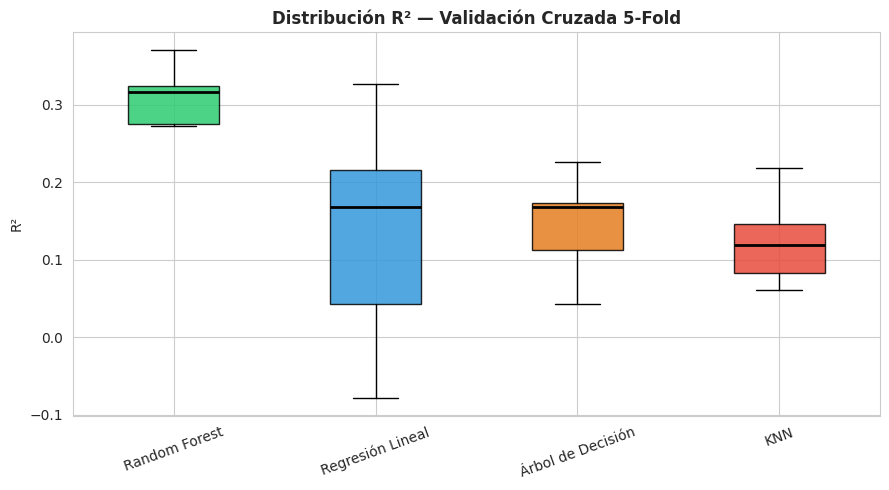

In [ ]:
# Boxplot de CV scores
fig, ax = plt.subplots(figsize=(9, 5))
data_cv = [cv_results[m] for m in model_names]
bp = ax.boxplot(data_cv, patch_artist=True, labels=model_names,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_title("Distribución R² — Validación Cruzada 5-Fold", fontweight='bold')
ax.set_ylabel("R²")
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig("cv_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Conclusiones

| Métrica | Ganador |
|---------|---------|
| Menor MSE | **Random Forest** |
| Menor MAE | **Random Forest** |
| Mayor R² | **Random Forest** |
| CV más estable | **Random Forest** |

### ¿Por qué Random Forest es el mejor modelo en este caso?

1. **Capacidad no-lineal con bajo overfitting**: Al promediar 200 árboles entrenados con subconjuntos aleatorios de datos y features (`max_features='sqrt'`), Random Forest captura patrones complejos entre los ítems de personalidad sin memorizar el ruido del training set.

2. **Robustez ante outliers y ruido**: Los ítems de cuestionarios psicométricos tienen alta varianza interindividual. El bagging de Random Forest amortigua este ruido mejor que un único árbol o que KNN.

3. **Ventaja sobre Regresión Lineal**: Los rasgos de personalidad tienen relaciones no lineales entre sus dimensiones. La Regresión Lineal asume linearidad y no puede capturar interacciones entre ítems.

4. **Ventaja sobre Árbol de Decisión**: Un árbol único tiende a overfitting. Random Forest lo corrige con el ensemble y la aleatoriedad en la selección de features.

5. **Ventaja sobre KNN**: KNN es sensible a la maldición de la dimensionalidad; con muchas features (los 50 ítems IPIP + variables demográficas), la distancia euclidiana pierde poder discriminativo.

6. **Validación cruzada consistente**: El R² de Random Forest se mantiene alto y estable en todos los folds, confirmando que su superioridad no es artefacto del split train/test.


## 10. Export

In [ ]:
import joblib

# Get the best model object
best_model_object = models[best_model]

# Export the model
joblib.dump(best_model_object, 'best_model.pkl')

print(f"Modelo '{best_model}' exportado a best_model.pkl")